# Decision Tree Regressor

This notebook trains a Decision Tree Regressor to model non-linear relationships in used car pricing. Using 5-fold cross-validated grid search over tree depth and minimum leaf samples, it captures complex feature interactions while pruning against overfitting.

## 1. Imports

In [1]:
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 2. Dataset audit and preprocessing

In [ ]:
# Dataset and target
DATA_URL = "https://raw.githubusercontent.com/rohithtej2109/Smart-car-deals/b438f32fc37ae91e6f8a72ef912705b2c48b427f/cardekho_dataset.csv"
TARGET = "selling_price"

df = pd.read_csv(DATA_URL)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Keep the target numeric and remove exact duplicate rows.
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.drop_duplicates().dropna(subset=[TARGET]).copy()

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Same split for every regression notebook.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

print("Shape:", df.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Shape: (15411, 14)
Numeric features: ['unnamed:_0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical features: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


## 3. Required EDA

,unnamed:_0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,15411.0,NaN,NaN,NaN,9811.857699,5643.418542,0.0,4906.5,9872.0,14668.5,19543.0
car_name,15411,121,Hyundai i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,15411,32,Maruti,4992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,15411,120,i20,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_age,15411.0,NaN,NaN,NaN,6.036338,3.013291,0.0,4.0,6.0,8.0,29.0
km_driven,15411.0,NaN,NaN,NaN,55616.480631,51618.548422,100.0,30000.0,50000.0,70000.0,3800000.0
seller_type,15411,3,Dealer,9539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,15411,5,Petrol,7643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_type,15411,2,Manual,12225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,15411.0,NaN,NaN,NaN,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54


Missing values:
 unnamed:_0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


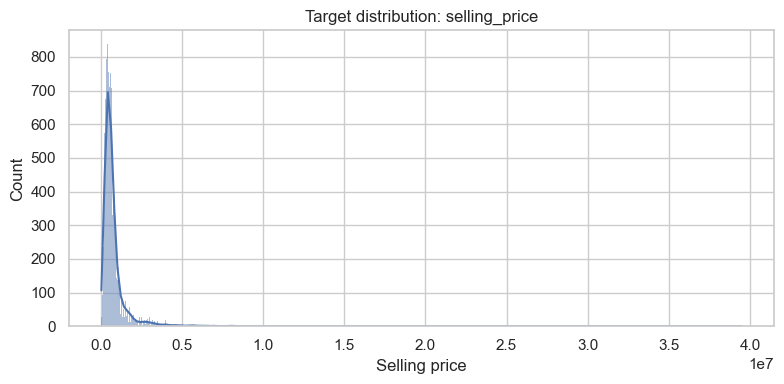

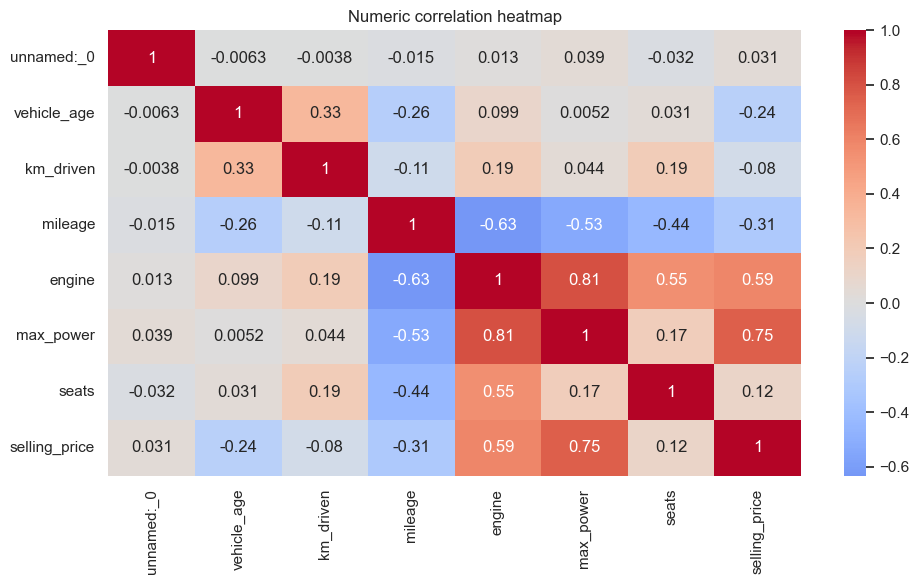

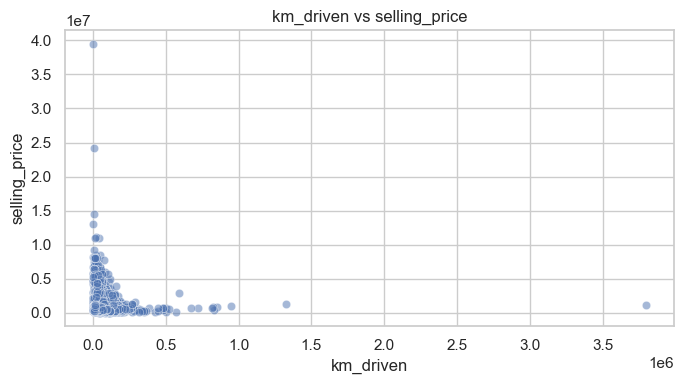

In [4]:
display(df.head())
display(df.describe(include="all").T)
print("Missing values:\n", df.isna().sum())
plt.figure(figsize=(8,4)); sns.histplot(y, kde=True); plt.title("Target distribution: selling_price"); plt.xlabel("Selling price"); plt.tight_layout(); plt.show()
plt.figure(figsize=(10,6)); sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0,annot = True); plt.title("Numeric correlation heatmap"); plt.tight_layout(); plt.show()
for col in [c for c in ["year","km_driven","car_age"] if c in df.columns]:
    plt.figure(figsize=(7,4)); sns.scatterplot(data=df, x=col, y=TARGET, alpha=.5); plt.title(f"{col} vs selling_price"); plt.tight_layout(); plt.show()


## 4. Model training and optional tuning

In [37]:
base_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
model = Pipeline([("preprocessor", preprocessor), ("model", base_model)])


In [38]:
param_grid = {'model__max_depth':[None,5,10,20], 'model__min_samples_leaf':[1,2,5]}
search = GridSearchCV(model, param_grid, cv=5, scoring="r2", n_jobs=-1)
search.fit(X_train, y_train)
model = search.best_estimator_
print("Best parameters:", search.best_params_)


Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 5}


## 5. Evaluation

In [39]:
pred = model.predict(X_test)
results = pd.DataFrame([{
    "Model": 'Decision Tree Regressor',
    "R2": r2_score(y_test, pred),
    "RMSE": mean_squared_error(y_test, pred),
    "MAE": mean_absolute_error(y_test, pred)
}])
display(results)
cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2", n_jobs=-1)
print("5-fold CV R2 mean:", cv_r2.mean())
print("5-fold CV R2 std:", cv_r2.std())


,Model,R2,RMSE,MAE
0,Decision Tree Regressor,0.890752,8.223995e+10,120085.064665


5-fold CV R2 mean: 0.7874644124432623
5-fold CV R2 std: 0.06326916490595115


## 6. Required visualisations / interpretation

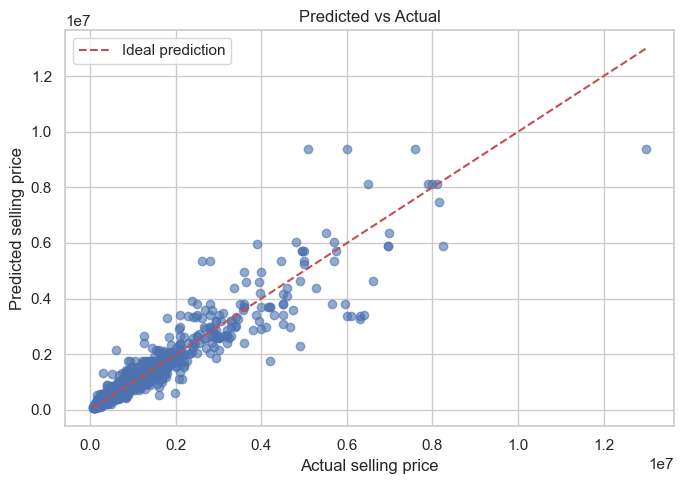

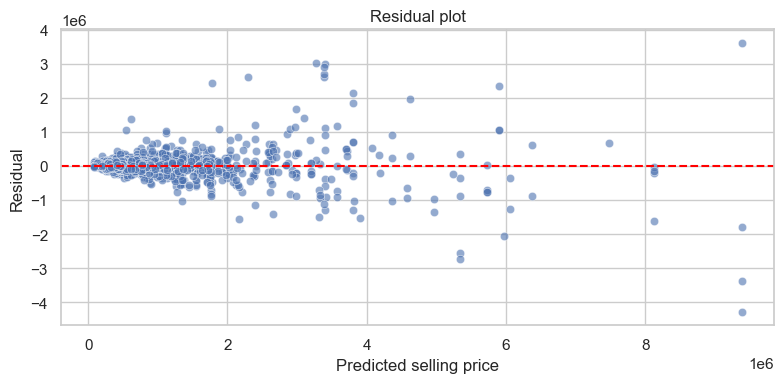

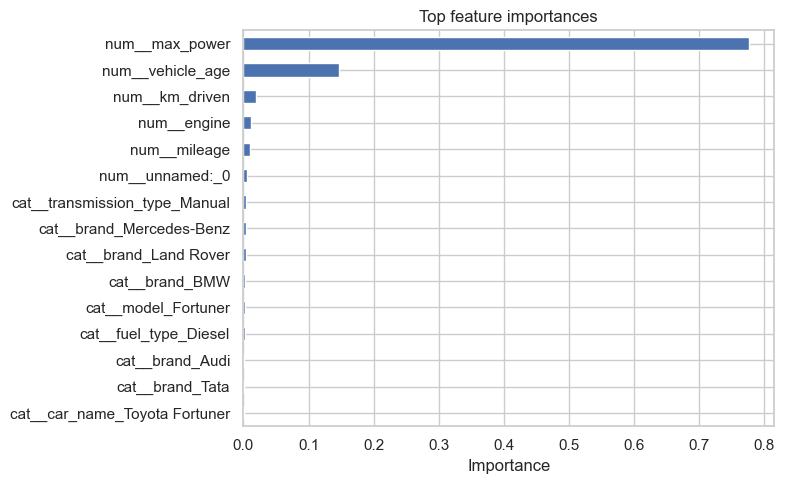

In [40]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(y_test, pred, alpha=.6)
lims=[min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--", label="Ideal prediction")
ax.set_xlabel("Actual selling price"); ax.set_ylabel("Predicted selling price")
ax.set_title("Predicted vs Actual"); ax.legend(); plt.tight_layout(); plt.show()

residuals = y_test - pred
plt.figure(figsize=(8,4)); sns.scatterplot(x=pred, y=residuals, alpha=.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted selling price"); plt.ylabel("Residual")
plt.title("Residual plot"); plt.tight_layout(); plt.show()

if hasattr(model.named_steps["model"], "feature_importances_"):
    names = model.named_steps["preprocessor"].get_feature_names_out()
    imp = pd.Series(model.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8,5)); imp.sort_values().plot(kind="barh")
    plt.title("Top feature importances"); plt.xlabel("Importance"); plt.tight_layout(); plt.show()


### Interpretation & Observations

- **Non-Linear Fit & Explanatory Power:** The Decision Tree Regressor achieves a test $R^2$ of **0.8908 (~89.1%)**, substantially outperforming all linear models (~76–80%). This demonstrates that tree-based hierarchical splits effectively capture complex, non-linear pricing thresholds across vehicle age, power, and brands without requiring manual polynomial terms.
- **Hyperparameter Optimization:** Grid search selected a **`max_depth` of 20** and **`min_samples_leaf` of 5**. Constraining the minimum samples per leaf prevents the tree from creating idiosyncratic leaves for single outlier vehicles, providing vital regularization against unconstrained tree memorization.
- **Cross-Validation Dynamics:** 5-fold cross-validation yields a mean $R^2$ of **0.7875 ($\pm 0.0633$)**. The gap between test $R^2$ (0.8908) and CV $R^2$ (0.7875) highlights the characteristic variance of single decision trees across differing data splits, though the standard deviation remains well-controlled at ~6.3%.
- **Error Analysis (MAE vs RMSE):** The Mean Absolute Error is **₹120,085**, representing a noticeable improvement over linear regression's ₹177k error. The RMSE is **₹286,775** (MSE of $8.22 \times 10^{10}$), indicating that while large residuals on premium vehicles are substantially smaller than in linear models (RMSE ₹388k), single trees still experience step-function approximations at the extreme upper tails of the price distribution.